In [1]:
# GNN using DGL libaray 
#https://lifesci.dgl.ai/api/utils.mols.html

In [ ]:
#The training dataset, intended solely for training purposes, has been imported, 
#featuring MACCS keys that represent the structural characteristics of the chemical compounds, 
#with each chemical labeled as 0 for non-developmental toxicants and 1 for developmental toxicants.

In [ ]:
import pandas as pd
import numpy as np

from dgllife.utils import smiles_to_bigraph
from sklearn.model_selection import train_test_split

import category_encoders as ce
from sklearn.preprocessing import StandardScaler
from dgllife.utils import one_hot_encoding
from sklearn.model_selection import train_test_split

In [3]:
import numpy as np
print(np.__version__)

1.23.5


In [ ]:
import dgl
from importlib import reload
reload(dgl)

In [5]:
import matplotlib.pyplot as plt
import os
from rdkit import Chem
from rdkit.Chem import rdmolops, rdmolfiles
from rdkit import RDPaths
 
import dgl
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
#from dgl import model_zoo
from dgllife.model import AttentiveFPPredictor
from dgllife.utils import mol_to_complete_graph, mol_to_bigraph
from dgllife.utils import atom_type_one_hot
from dgllife.utils import atom_degree_one_hot
from dgllife.utils import atom_formal_charge
from dgllife.utils import atom_num_radical_electrons
from dgllife.utils import atom_hybridization_one_hot
from dgllife.utils import atom_total_num_H_one_hot
from dgllife.utils import one_hot_encoding
from dgllife.utils import CanonicalAtomFeaturizer
from dgllife.utils import CanonicalBondFeaturizer
from dgllife.utils import ConcatFeaturizer
from dgllife.utils import BaseAtomFeaturizer
from dgllife.utils import BaseBondFeaturizer
from dgllife.utils import one_hot_encoding 
from dgl.data.utils import split_dataset
from dgllife.utils import CanonicalBondFeaturizer
 
from functools import partial
from sklearn.metrics import roc_auc_score

In [6]:
from dgllife.utils import smiles_to_bigraph

In [7]:
import torch
from rdkit import Chem
from dgllife.utils import smiles_to_bigraph

In [8]:
mol = Chem.MolFromSmiles('CCO')
bond_featurizer = CanonicalBondFeaturizer(bond_data_field='feat')
bond_featurizer(mol)['feat']

tensor([[1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [9]:
#Function imported from DGL 

In [10]:
def chirality(atom):
    try:
        return one_hot_encoding(atom.GetProp('_CIPCode'), ['R', 'S']) + \
               [atom.HasProp('_ChiralityPossible')]
    except:
        return [False, False] + [atom.HasProp('_ChiralityPossible')]
     
def collate_molgraphs(data):
    """Batching a list of datapoints for dataloader.
    Parameters
    ----------
    data : list of 3-tuples or 4-tuples.
        Each tuple is for a single datapoint, consisting of
        a SMILES, a DGLGraph, all-task labels and optionally
        a binary mask indicating the existence of labels.
    Returns
    -------
    smiles : list
        List of smiles
    bg : BatchedDGLGraph
        Batched DGLGraphs
    labels : Tensor of dtype float32 and shape (B, T)
        Batched datapoint labels. B is len(data) and
        T is the number of total tasks.
    masks : Tensor of dtype float32 and shape (B, T)
        Batched datapoint binary mask, indicating the
        existence of labels. If binary masks are not
        provided, return a tensor with ones.
    """
    assert len(data[0]) in [3, 4], \
        'Expect the tuple to be of length 3 or 4, got {:d}'.format(len(data[0]))
    if len(data[0]) == 3:
        smiles, graphs, labels = map(list, zip(*data))
        masks = None
    else:
        smiles, graphs, labels, masks = map(list, zip(*data))
 
    bg = dgl.batch(graphs)
    bg.set_n_initializer(dgl.init.zero_initializer)
    bg.set_e_initializer(dgl.init.zero_initializer)
    labels = torch.stack(labels, dim=0)
     
    if masks is None:
        masks = torch.ones(labels.shape)
    else:
        masks = torch.stack(masks, dim=0)
    return smiles, bg, labels, masks

In [11]:
# this AttentiveFPPredictor(nn.Module) is imported from DGL 

In [12]:
import torch.nn as nn

from dgllife.model import AttentiveFPGNN
from dgllife.model import AttentiveFPReadout

__all__ = ['AttentiveFPPredictor']

# pylint: disable=W0221
class AttentiveFPPredictor(nn.Module):
    """AttentiveFP for regression and classification on graphs.

    AttentiveFP is introduced in
    `Pushing the Boundaries of Molecular Representation for Drug Discovery with the Graph
    Attention Mechanism. <https://www.ncbi.nlm.nih.gov/pubmed/31408336>`__

    Parameters
    ----------
    node_feat_size : int
        Size for the input node features.
    edge_feat_size : int
        Size for the input edge features.
    num_layers : int
        Number of GNN layers. Default to 2.
    num_timesteps : int
        Times of updating the graph representations with GRU. Default to 2.
    graph_feat_size : int
        Size for the learned graph representations. Default to 200.
    n_tasks : int
        Number of tasks, which is also the output size. Default to 1.
    dropout : float
        Probability for performing the dropout. Default to 0.
    """
    def __init__(self,
                 node_feat_size,
                 edge_feat_size,
                 num_layers=2,
                 num_timesteps=2,
                 graph_feat_size=200,
                 n_tasks=1,
                 dropout=0.):
        super(AttentiveFPPredictor, self).__init__()

        self.gnn = AttentiveFPGNN(node_feat_size=node_feat_size,
                                  edge_feat_size=edge_feat_size,
                                  num_layers=num_layers,
                                  graph_feat_size=graph_feat_size,
                                  dropout=dropout)
        self.readout = AttentiveFPReadout(feat_size=graph_feat_size,
                                          num_timesteps=num_timesteps,
                                          dropout=dropout)
        self.predict = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(graph_feat_size, n_tasks)
        )

    def forward(self, g, node_feats, edge_feats, get_node_weight=False):
        """Graph-level regression/soft classification.

        Parameters
        ----------
        g : DGLGraph
            DGLGraph for a batch of graphs.
        node_feats : float32 tensor of shape (V, node_feat_size)
            Input node features. V for the number of nodes.
        edge_feats : float32 tensor of shape (E, edge_feat_size)
            Input edge features. E for the number of edges.
        get_node_weight : bool
            Whether to get the weights of atoms during readout. Default to False.

        Returns
        -------
        float32 tensor of shape (G, n_tasks)
            Prediction for the graphs in the batch. G for the number of graphs.
        node_weights : list of float32 tensor of shape (V, 1), optional
            This is returned when ``get_node_weight`` is ``True``.
            The list has a length ``num_timesteps`` and ``node_weights[i]``
            gives the node weights in the i-th update.
        """
        node_feats = self.gnn(g, node_feats, edge_feats)
        if get_node_weight:
            g_feats, node_weights = self.readout(g, node_feats, get_node_weight)
            return self.predict(g_feats), node_weights
        else:
            g_feats = self.readout(g, node_feats, get_node_weight)
            return self.predict(g_feats), g_feats

In [13]:
# collate_molgraph function is directly imported from DGL to concat 5 chemical structure as a minibatch

In [14]:
def collate_molgraphs(data):
    """Batching a list of datapoints for dataloader.
    Parameters
    ----------
    data : list of 3-tuples or 4-tuples.
        Each tuple is for a single datapoint, consisting of
        a SMILES, a DGLGraph, all-task labels and optionally
        a binary mask indicating the existence of labels.
    Returns
    -------
    smiles : list
        List of smiles
    bg : BatchedDGLGraph
        Batched DGLGraphs
    labels : Tensor of dtype float32 and shape (B, T)
        Batched datapoint labels. B is len(data) and
        T is the number of total tasks.
    masks : Tensor of dtype float32 and shape (B, T)
        Batched datapoint binary mask, indicating the
        existence of labels. If binary masks are not
        provided, return a tensor with ones.
    """
    assert len(data[0]) in [3, 4], \
        'Expect the tuple to be of length 3 or 4, got {:d}'.format(len(data[0]))
    if len(data[0]) == 3:
        smiles, graphs, labels = map(list, zip(*data))
        masks = None
    else:
        smiles, graphs, labels, masks = map(list, zip(*data))
 
    bg = dgl.batch(graphs)
    bg.set_n_initializer(dgl.init.zero_initializer)
    bg.set_e_initializer(dgl.init.zero_initializer)
    labels = [torch.tensor(label) if isinstance(label, int) else label for label in labels]

    labels = torch.stack(labels, dim=0)
     
    if masks is None:
        masks = torch.ones(labels.shape)
    else:
        masks = torch.stack(masks, dim=0)
    return smiles, bg, labels, masks

In [5]:
df3=pd.read_excel('gnn_dev_training_data.xlsx')

In [6]:
df3

,SMILE,comparr,value
0,CC(C)CN(CC(C)C)C(=S)SSC(=S)N(CC(C)C)CC(C)C,<rdkit.Chem.rdchem.Mol object at 0x0000022D4B5...,0
1,FC(F)(F)C(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)F,<rdkit.Chem.rdchem.Mol object at 0x0000022D4B5...,0
2,OCCCCCCCCCO,<rdkit.Chem.rdchem.Mol object at 0x0000022D4B5...,0
3,C(CC=CCCCCCCCC(=O)[O-])=CCC.[N+](CC[O-])(CC[O-...,<rdkit.Chem.rdchem.Mol object at 0x0000022D4B5...,0
4,[N+](CC[O-])(CC[O-])CC[O-].C12=CCC3(C(C1CCC(=C...,<rdkit.Chem.rdchem.Mol object at 0x0000022D4B5...,0
...,...,...,...
994,CCOc1snc(n1)C(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x0000022D545...,1
995,[Na+].[Na+].COc1cc(c(C)cc1N\N=C2\C(=O)C=Cc3cc(...,<rdkit.Chem.rdchem.Mol object at 0x0000022D545...,1
996,[Na+].[Na+].[Na+].[Na+].Nc1cc(cc2C=C(\C(=N/Nc3...,<rdkit.Chem.rdchem.Mol object at 0x0000022D545...,1
997,C[C@@H]1CC2C3C[C@H](F)C4=CC(=O)C=CC4(C)[C@@]3(...,<rdkit.Chem.rdchem.Mol object at 0x0000022D545...,1


In [ ]:
#import dgl 

In [16]:
from rdkit import Chem
from dgllife.utils import CanonicalAtomFeaturizer
from dgllife.utils import CanonicalBondFeaturizer

In [ ]:
# split the data 

In [17]:
X3=df3['SMILE ']
y=df3['value']
X_trainval, X_test, y_trainval, y_test=train_test_split(X3, y, random_state=42)
X_train, X_valid, y_train, y_valid=train_test_split(X_trainval, y_trainval, random_state=1)

In [ ]:
# construct graph dataset 

In [18]:
train_smi =[sm for sm in X_train]
train_mols=[Chem.MolFromSmiles(sm) for sm in train_smi]
train_value =[y for y in y_train]


 

valid_smi = X_valid
valid_mols=[Chem.MolFromSmiles(sm) for sm in valid_smi]
valid_value = y_valid

test_smi = X_test
test_mols=[Chem.MolFromSmiles(sm) for sm in test_smi]
test_value = y_test


 
train_graph =[mol_to_bigraph(mol,
                           node_featurizer=CanonicalAtomFeaturizer(atom_data_field='atomic'), 
                      edge_featurizer=CanonicalBondFeaturizer(bond_data_field='feat')) for mol in train_mols]
 
valid_graph =[mol_to_bigraph(mol, node_featurizer=CanonicalAtomFeaturizer(atom_data_field='atomic'), 
                      edge_featurizer=CanonicalBondFeaturizer(bond_data_field='feat')) for mol in valid_mols]

test_graph =[mol_to_bigraph(mol, node_featurizer=CanonicalAtomFeaturizer(atom_data_field='atomic'), 
                      edge_featurizer=CanonicalBondFeaturizer(bond_data_field='feat')) for mol in test_mols]




In [ ]:
#build the dataloader 

In [19]:

 
train_loader = DataLoader(dataset=list(zip(train_smi, train_graph, train_value)), batch_size=5, collate_fn=collate_molgraphs,shuffle=True)
valid_loader = DataLoader(dataset=list(zip(valid_smi, valid_graph, valid_value)), batch_size=5, collate_fn=collate_molgraphs,shuffle=True)
test_loader = DataLoader(dataset=list(zip(test_smi, test_graph, test_value)), batch_size=5, collate_fn=collate_molgraphs,shuffle=True)


In [ ]:
#construct GNN model with predefined hyperparameters 

In [20]:
model = AttentiveFPPredictor(node_feat_size=74,
                                  edge_feat_size=12,
                                  num_layers=4,
                                  num_timesteps=3,
                                  graph_feat_size=200,
                                  n_tasks=2,
                                  dropout=0.458)
#model = model.to('cuda:0')

In [ ]:
# build train and test epoch 

In [21]:
def run_a_train_epoch_loss_auc(n_epochs, epoch, model, data_loader,loss_criterion, optimizer):
    model.train()
    total_loss = 0
    losses = []
    train_true_labels=[]
    train_pred_probs=[]
    
    for batch_id, batch_data in enumerate(train_loader):
        smiles, bg, labels, masks= batch_data


        if torch.cuda.is_available():
            bg.to(torch.device('cuda:0'))
            labels = labels.to('cuda:0')
            masks = masks.to('cuda:0')
            
        optimizer.zero_grad() 
        prediction,_ = model(bg, bg.ndata['atomic'], bg.edata['feat'])
        loss = (loss_criterion(prediction, labels).float()).mean()
        loss.backward()
        optimizer.step()
         
        losses.append(loss.data.item())

        logits=prediction.detach().numpy()
        pred_probs = 1 / (1 + np.exp(-logits[:, 1]))
        train_true_labels.extend(labels)
        train_pred_probs.extend(pred_probs)         
 
    total_score = np.mean(losses)
    roc_auc = roc_auc_score(train_true_labels, train_pred_probs)

    return total_score, roc_auc

In [22]:
def run_a_validation_epoch_loss_auc(n_epochs, epoch, model, data_loader,loss_criterion, optimizer):
    model.eval()
    total_loss = 0
    losses = []
    val_true_labels=[]
    val_pred_probs=[]
    
    with torch.no_grad(): 
        for batch_id, batch_data in enumerate(valid_loader):
            batch_data
            smiles, bg, labels, masks= batch_data
#        labels = [torch.tensor(label) if isinstance(label, int) else label for label in labels]

            if torch.cuda.is_available():
                bg.to(torch.device('cuda:0'))
                labels = labels.to('cuda:0')
                masks = masks.to('cuda:0')
                
            optimizer.zero_grad()
            prediction,_ = model(bg, bg.ndata['atomic'], bg.edata['feat'])
#        print(prediction)
            loss = (loss_criterion(prediction, labels).float()).mean()
        #loss = loss_criterion(prediction, labels)
        #print(loss.shape)
            optimizer.zero_grad()

         
            losses.append(loss.data.item())
            
# generate roc auc 
            logits=prediction.cpu().numpy()
            pred_probs = 1 / (1 + np.exp(-logits[:, 1]))
            val_true_labels.extend(labels)
            val_pred_probs.extend(pred_probs)
            
        roc_auc = roc_auc_score(val_true_labels, val_pred_probs)
        total_score = np.mean(losses)
    return total_score, roc_auc    

In [23]:
def run_a_test_epoch_proba( model, data_loader,loss_criterion, optimizer):
    model.eval()
    total_loss = 0
    losses = []
    val_true_labels=[]
    val_pred_probs=[]
    with torch.no_grad(): 
        for batch_id, batch_data in enumerate(test_loader):
            batch_data
            smiles, bg, labels, masks= batch_data
            
            true_labels = labels.cpu().numpy()
#            prediction = model(bg, bg.ndata['atomic'], bg.edata['feat']).cpu().numpy()[:, 1]  # Assuming binary classification
            logits,_ = model(bg, bg.ndata['atomic'], bg.edata['feat']).cpu().numpy()
#            val_pred_probs= torch.sigmoid(prediction)
            pred_probs = 1 / (1 + np.exp(-logits[:, 1]))
            val_true_labels.extend(true_labels)
            val_pred_probs.extend(pred_probs)

         
#            losses.append(loss.data.item())
         
        roc_auc = roc_auc_score(val_true_labels, val_pred_probs)

    return val_pred_probs, val_true_labels

In [ ]:
# set up the loss function and optimizer 

In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0000001)

In [25]:
from dgl import init

In [ ]:
# start the training cycles 

In [26]:
loss_fn = nn.CrossEntropyLoss()
#loss_fn=nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0000001)
patience = 100  # Number of epochs to wait for improvement
best_val_loss = float('inf')
best_auc = float('inf')
counter = 0  # Counter to track the number of epochs without improvement
n_epochs = 500
train_epochs = []
train_loss_total = []
validation_epoches=[]
validation_loss_total=[]
train_roc_auc_total=[]
epochs=[]
valid_roc_auc_total=[]
best_roc_auc = 0
for e in range(n_epochs):
    
    train_loss,train_roc_auc = run_a_train_epoch_loss_auc(n_epochs, e, model, train_loader, loss_fn, optimizer)

    train_epochs.append(e)
    train_loss_total.append(train_loss)
    
    
    val_loss,valid_roc_auc = run_a_validation_epoch_loss_auc(n_epochs, e, model, valid_loader, loss_fn, optimizer)

    validation_epoches.append(e)
    validation_loss_total.append(val_loss)


    valid_roc_auc_total.append(valid_roc_auc)

    train_roc_auc_total.append(train_roc_auc)


 
    print(f'Epoch {e + 1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, ROC AUC: {valid_roc_auc:.4f}')
    epochs.append(e)


    # Early stopping based on ROC AUC
    if valid_roc_auc > best_roc_auc:
        best_roc_auc = valid_roc_auc
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f'Early stopping after {e + 1} epochs without improvement in ROC AUC.')
        break


Epoch 1/500, Train Loss: 0.6466, Val Loss: 0.6508, ROC AUC: 0.6318
Epoch 2/500, Train Loss: 0.6119, Val Loss: 0.6274, ROC AUC: 0.6933
Epoch 3/500, Train Loss: 0.5830, Val Loss: 0.6541, ROC AUC: 0.6875
Epoch 4/500, Train Loss: 0.5830, Val Loss: 0.6096, ROC AUC: 0.7003
Epoch 5/500, Train Loss: 0.5673, Val Loss: 0.6227, ROC AUC: 0.6922
Epoch 6/500, Train Loss: 0.5583, Val Loss: 0.6137, ROC AUC: 0.7015
Epoch 7/500, Train Loss: 0.5539, Val Loss: 0.6566, ROC AUC: 0.6957
Epoch 8/500, Train Loss: 0.5396, Val Loss: 0.6413, ROC AUC: 0.6962
Epoch 9/500, Train Loss: 0.5342, Val Loss: 0.6483, ROC AUC: 0.6874
Epoch 10/500, Train Loss: 0.5179, Val Loss: 0.6294, ROC AUC: 0.6983
Epoch 11/500, Train Loss: 0.5092, Val Loss: 0.6470, ROC AUC: 0.6963
Epoch 12/500, Train Loss: 0.4978, Val Loss: 0.6407, ROC AUC: 0.7067
Epoch 13/500, Train Loss: 0.4944, Val Loss: 0.6609, ROC AUC: 0.6977
Epoch 14/500, Train Loss: 0.4920, Val Loss: 0.6248, ROC AUC: 0.7141
Epoch 15/500, Train Loss: 0.4873, Val Loss: 0.6742, ROC A

In [ ]:
#plot the train loss and valid loss 

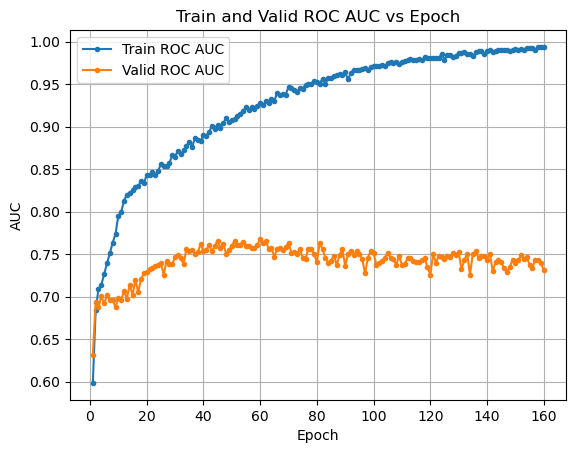

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



# Training loop
num_epochs = len(valid_roc_auc_total)  # Set the number of epochs
train_roc_auc = train_roc_auc_total # List to store training losses for each epoch
valid_roc_auc = valid_roc_auc_total  # List to store validation losses for each epoch



# Plot the Train Loss and Valid Loss vs Epoch
plt.plot(range(1, num_epochs + 1), train_roc_auc, marker='.', label='Train ROC AUC')
plt.plot(range(1, num_epochs + 1), valid_roc_auc, marker='.', label='Valid ROC AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Train and Valid ROC AUC vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prediction based chemical smiles 

In [30]:
def gcn_prediction(smi):
    mol=Chem.MolFromSmiles(smi) 
    bg =mol_to_bigraph(mol, node_featurizer=CanonicalAtomFeaturizer(atom_data_field='atomic'), 
                      edge_featurizer=CanonicalBondFeaturizer(bond_data_field='feat')) 
    
    logit, _ = model(bg, bg.ndata['atomic'], bg.edata['feat'])

    logits=logit.detach().numpy()
    pred_probs = 1 / (1 + np.exp(-logits[:, 1]))

    return pred_probs
    

In [31]:
gcn_prediction('C1=C3C(=CC(=C1C(=CC2=CC=C(C=C2)C(=O)O)C)C)C(CCC3(C)C)(C)C')

array([0.9862394], dtype=float32)